
===== IBI QUALITY METRICS =====

Noise        | Raw: 0.077135 | Filtered: 0.028177
Spikes       | Raw: 12 | Filtered: 3
Smoothness   | Raw: 0.056419 | Filtered: 0.016042
Consistency  | Raw: 0.104843 | Filtered: 0.087358


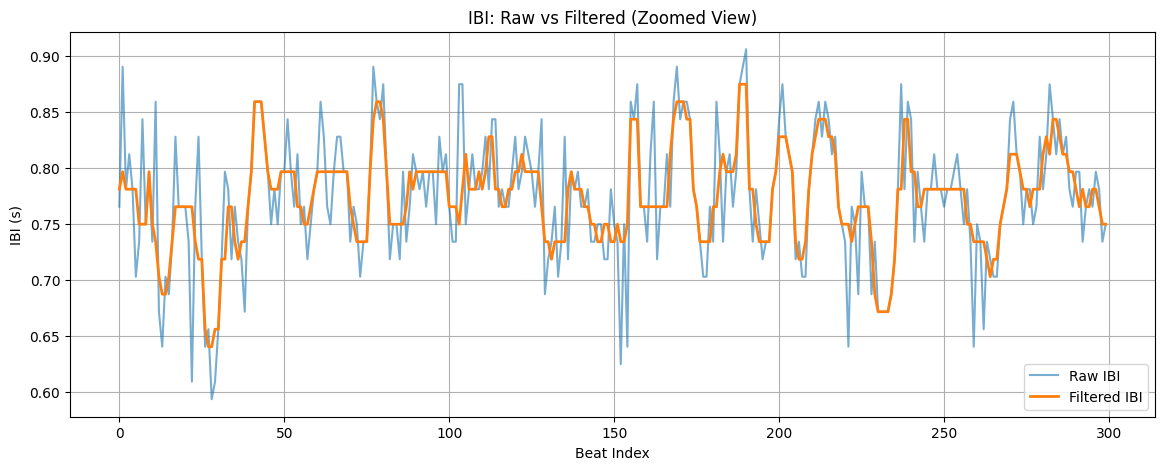

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

# =========================
# 1. LOAD & CLEAN IBI
# =========================
file_path = "../../data/raw/WESAD/S2/S2_E4_Data/IBI.csv"

df = pd.read_csv(file_path, sep="\t", header=None, comment="#")

# split into timestamp and ibi
df = df[0].str.split(",", expand=True)
df.columns = ["timestamp", "ibi"]

# convert numeric
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["ibi"] = pd.to_numeric(df["ibi"], errors="coerce")

# remove NaN
df = df.dropna()

# physiological filtering (valid IBI range)
df = df[(df["ibi"] >= 0.3) & (df["ibi"] <= 2.0)]

# sort by time
df = df.sort_values("timestamp").reset_index(drop=True)

raw_ibi = df["ibi"].values

# =========================
# 2. INTERPOLATION
# =========================
ibi_interp = pd.Series(raw_ibi).interpolate().bfill().ffill().values

# =========================
# 3. SMOOTHING (MEDIAN FILTER)
# =========================
ibi_filtered = pd.Series(ibi_interp).rolling(
    window=5, center=True, min_periods=1
).median().values

# =========================
# 4. ALIGN LENGTH
# =========================
n = min(len(raw_ibi), len(ibi_filtered))
raw = raw_ibi[:n]
filtered = ibi_filtered[:n]

# =========================
# 5. QUALITY METRICS
# =========================
noise_raw = np.std(np.diff(raw))
noise_filtered = np.std(np.diff(filtered))

spikes_raw = np.sum(np.abs(zscore(raw)) > 3)
spikes_filtered = np.sum(np.abs(zscore(filtered)) > 3)

smooth_raw = np.mean(np.abs(np.diff(raw)))
smooth_filtered = np.mean(np.abs(np.diff(filtered)))

cv_raw = np.std(raw) / np.mean(raw)
cv_filtered = np.std(filtered) / np.mean(filtered)

print("\n===== IBI QUALITY METRICS =====\n")

print(f"Noise        | Raw: {noise_raw:.6f} | Filtered: {noise_filtered:.6f}")
print(f"Spikes       | Raw: {spikes_raw} | Filtered: {spikes_filtered}")
print(f"Smoothness   | Raw: {smooth_raw:.6f} | Filtered: {smooth_filtered:.6f}")
print(f"Consistency  | Raw: {cv_raw:.6f} | Filtered: {cv_filtered:.6f}")

# =========================
# 6. VISUALIZATION
# =========================
plt.figure(figsize=(14,5))
plt.plot(raw[:300], label="Raw IBI", alpha=0.6)
plt.plot(filtered[:300], label="Filtered IBI", linewidth=2)

plt.title("IBI: Raw vs Filtered (Zoomed View)")
plt.xlabel("Beat Index")
plt.ylabel("IBI (s)")
plt.legend()
plt.grid()
plt.show()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

# =========================
# RAW SIGNAL
# =========================
raw_ibi = df_clean["ibi"].values

# =========================
# PREPROCESSING
# =========================
ibi_interp = pd.Series(raw_ibi).interpolate().bfill().ffill().values

ibi_filtered = pd.Series(ibi_interp).rolling(
    window=5, center=True, min_periods=1
).median().values

# =========================
# ALIGN LENGTH
# =========================
n = min(len(raw_ibi), len(ibi_filtered))

raw = raw_ibi[:n]
filtered = ibi_filtered[:n]

# =========================
# QUALITY METRICS
# =========================
noise_raw = np.std(np.diff(raw))
noise_filtered = np.std(np.diff(filtered))

spikes_raw = np.sum(np.abs(zscore(raw)) > 3)
spikes_filtered = np.sum(np.abs(zscore(filtered)) > 3)

smooth_raw = np.mean(np.abs(np.diff(raw)))
smooth_filtered = np.mean(np.abs(np.diff(filtered)))

cv_raw = np.std(raw) / np.mean(raw)
cv_filtered = np.std(filtered) / np.mean(filtered)

print("\n===== IBI QUALITY METRICS =====\n")

print(f"Noise        | Raw: {noise_raw:.6f} | Filtered: {noise_filtered:.6f}")
print(f"Spikes       | Raw: {spikes_raw} | Filtered: {spikes_filtered}")
print(f"Smoothness   | Raw: {smooth_raw:.6f} | Filtered: {smooth_filtered:.6f}")
print(f"Consistency  | Raw: {cv_raw:.6f} | Filtered: {cv_filtered:.6f}")

NameError: name 'df_clean' is not defined

In [6]:
import pandas as pd
import numpy as np

# =========================
# LOAD IBI FILE
# =========================
file_path = "../../data/raw/WESAD/S2/S2_E4_Data/IBI.csv"

df = pd.read_csv(file_path, sep="\t", header=None, comment="#")

# split into timestamp and ibi
df = df[0].str.split(",", expand=True)
df.columns = ["timestamp", "ibi"]

# convert to numeric
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["ibi"] = pd.to_numeric(df["ibi"], errors="coerce")

# =========================
# CLEAN DATA
# =========================
df = df.dropna().copy()

# physiological range filter (0.3s to 2s)
df = df[(df["ibi"] >= 0.3) & (df["ibi"] <= 2.0)]

# sort by time
df = df.sort_values("timestamp").reset_index(drop=True)

ibi = df["ibi"].values

# =========================
# INTERPOLATION (optional but safe)
# =========================
ibi = pd.Series(ibi).interpolate().bfill().ffill().values

# =========================
# SMOOTHING
# =========================
ibi = pd.Series(ibi).rolling(window=5, center=True, min_periods=1).median().values

# =========================
# FINAL OUTPUT
# =========================
print("Final IBI shape:", ibi.shape)
print("Sample values:", ibi[:10])

Final IBI shape: (3458,)
Sample values: [0.781286  0.7969115 0.781286  0.781286  0.781286  0.781286  0.750034
 0.750034  0.750034  0.796911 ]


In [ ]:
import pandas as pd

file_path = "../../data/raw/WESAD/S2/S2_E4_Data/IBI.csv" 

df = pd.read_csv(file_path, sep="\t", header=None, comment="#")

# split the single column into 2
df_split = df[0].str.split(",", expand=True)

df_split.columns = ["timestamp", "ibi"]

# convert to numeric
df_split["timestamp"] = pd.to_numeric(df_split["timestamp"], errors="coerce")
df_split["ibi"] = pd.to_numeric(df_split["ibi"], errors="coerce")

print(df_split.head())
print(df_split.dtypes)

      timestamp       ibi
0  1.495437e+09       NaN
1  1.431316e+01  0.765660
2  1.520382e+01  0.890666
3  1.598511e+01  0.781286
4  1.679764e+01  0.812537
timestamp    float64
ibi          float64
dtype: object


In [ ]:
import pandas as pd

file_path = "../../data/raw/WESAD/S2/S2_E4_Data/IBI.csv"  # change this if needed

# load file
df = pd.read_csv(file_path, sep="\t", header=None, comment="#")

print("Shape:", df.shape)
print(df.head())

Shape: (3459, 1)
                        0
0  1495437325.000000, IBI
1      14.313155,0.765660
2      15.203821,0.890666
3      15.985107,0.781286
4      16.797644,0.812537


In [ ]:
# remove NaN IBI
df_clean = df_split.dropna(subset=["ibi"]).copy()

# remove physiological outliers (in seconds)
# normal IBI range: ~0.3s to 2.0s
df_clean = df_clean[(df_clean["ibi"] >= 0.3) & (df_clean["ibi"] <= 2.0)]

print("Before:", df_split.shape)
print("After cleaning:", df_clean.shape)
print(df_clean.head())

Before: (3459, 2)
After cleaning: (3458, 2)
   timestamp       ibi
1  14.313155  0.765660
2  15.203821  0.890666
3  15.985107  0.781286
4  16.797644  0.812537
5  17.578930  0.781286


In [ ]:
df_clean = df_clean.sort_values("timestamp").reset_index(drop=True)

ibi = df_clean["ibi"].values

print(ibi[:10])

[0.76566  0.890666 0.781286 0.812537 0.781286 0.703157 0.734409 0.843789
 0.750034 0.796911]


In [ ]:
import pandas as pd
import numpy as np

# convert to series for safe processing
ibi_series = pd.Series(ibi)

# interpolate missing values (if any)
ibi_interp = ibi_series.interpolate(method="linear")

# fill remaining edge NaNs (if any)
ibi_interp = ibi_interp.bfill().ffill()

print(ibi_interp.head(10))
print("Missing values after:", ibi_interp.isna().sum())

0    0.765660
1    0.890666
2    0.781286
3    0.812537
4    0.781286
5    0.703157
6    0.734409
7    0.843789
8    0.750034
9    0.796911
dtype: float64
Missing values after: 0


Step 6: Median filter (remove spikes)

In [ ]:
import numpy as np
import pandas as pd

ibi_clean = ibi_interp.values

# median smoothing (window = 5 beats)
ibi_filtered = pd.Series(ibi_clean).rolling(
    window=5, center=True, min_periods=1
).median().values

print(ibi_filtered[:10])

[0.781286  0.7969115 0.781286  0.781286  0.781286  0.781286  0.750034
 0.750034  0.750034  0.796911 ]


In [ ]:
import numpy as np
from scipy.stats import zscore

raw = ibi
filtered = ibi_filtered

# ensure same length
n = min(len(raw), len(filtered))
raw = raw[:n]
filtered = filtered[:n]

# 1. Noise (variation in consecutive differences)
noise_raw = np.std(np.diff(raw))
noise_filtered = np.std(np.diff(filtered))

# 2. Spike count (z-score outliers > 3)
spikes_raw = np.sum(np.abs(zscore(raw)) > 3)
spikes_filtered = np.sum(np.abs(zscore(filtered)) > 3)

# 3. Smoothness (average absolute change)
smooth_raw = np.mean(np.abs(np.diff(raw)))
smooth_filtered = np.mean(np.abs(np.diff(filtered)))

print("===== IBI QUALITY COMPARISON =====\n")

print(f"Noise (std diff)   | Raw: {noise_raw:.6f} | Filtered: {noise_filtered:.6f}")
print(f"Spike Count        | Raw: {spikes_raw} | Filtered: {spikes_filtered}")
print(f"Smoothness         | Raw: {smooth_raw:.6f} | Filtered: {smooth_filtered:.6f}")

===== IBI QUALITY COMPARISON =====

Noise (std diff)   | Raw: 0.077135 | Filtered: 0.028177
Spike Count        | Raw: 12 | Filtered: 3
Smoothness         | Raw: 0.056419 | Filtered: 0.016042


In [ ]:
import pandas as pd

# full cleaned signal
ibi_full = ibi_interp.values

# median filter on full signal
ibi_full_filtered = pd.Series(ibi_full).rolling(
    window=5, center=True, min_periods=1
).median().values

print("Full raw length:", len(ibi_full))
print("Full filtered length:", len(ibi_full_filtered))

print("\nFirst 10 filtered values:")
print(ibi_full_filtered[:10])

Full raw length: 3458
Full filtered length: 3458

First 10 filtered values:
[0.781286  0.7969115 0.781286  0.781286  0.781286  0.781286  0.750034
 0.750034  0.750034  0.796911 ]


1. filter

In [ ]:
import pandas as pd

# full cleaned signal
ibi_full = ibi_interp.values

# median filter on full signal
ibi_full_filtered = pd.Series(ibi_full).rolling(
    window=5, center=True, min_periods=1
).median().values

print("Full raw length:", len(ibi_full))
print("Full filtered length:", len(ibi_full_filtered))

print("\nFirst 10 filtered values:")
print(ibi_full_filtered[:10])

2. PLOTS

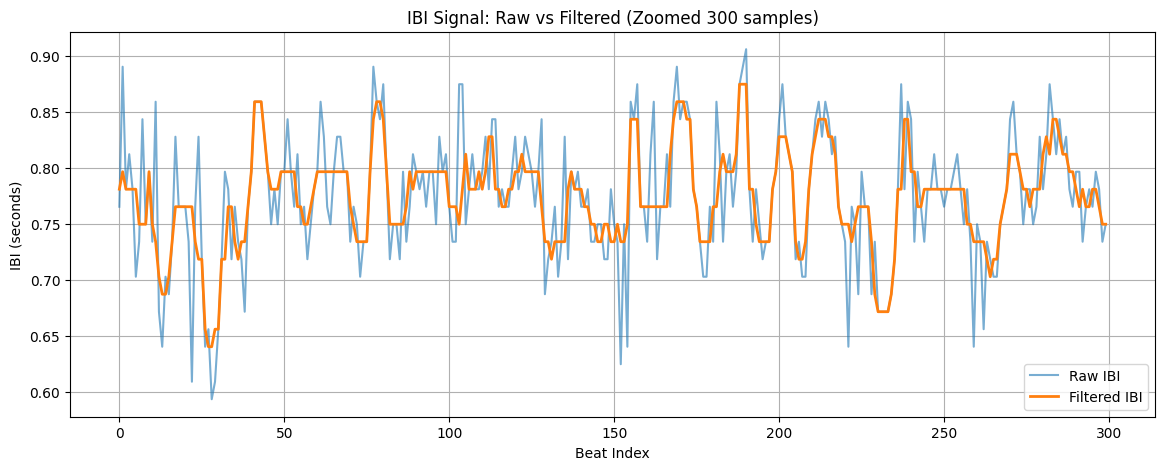

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,4))
plt.figure(figsize=(12,5))

start = 0
end = 3000

 
plt.plot(ibi_filtered[start:end], label='Filtered BVP')


plt.title("Filtered ibi")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()
plt.figure(figsize=(14,5))

plt.plot(raw_ibi[:300], label="Raw IBI", alpha=0.6)
plt.plot(ibi_filtered[:300], label="Filtered IBI", linewidth=2)

plt.title("IBI Signal: Raw vs Filtered (Zoomed 300 samples)")
plt.xlabel("Beat Index")
plt.ylabel("IBI (seconds)")
plt.legend()
plt.grid()
plt.show()

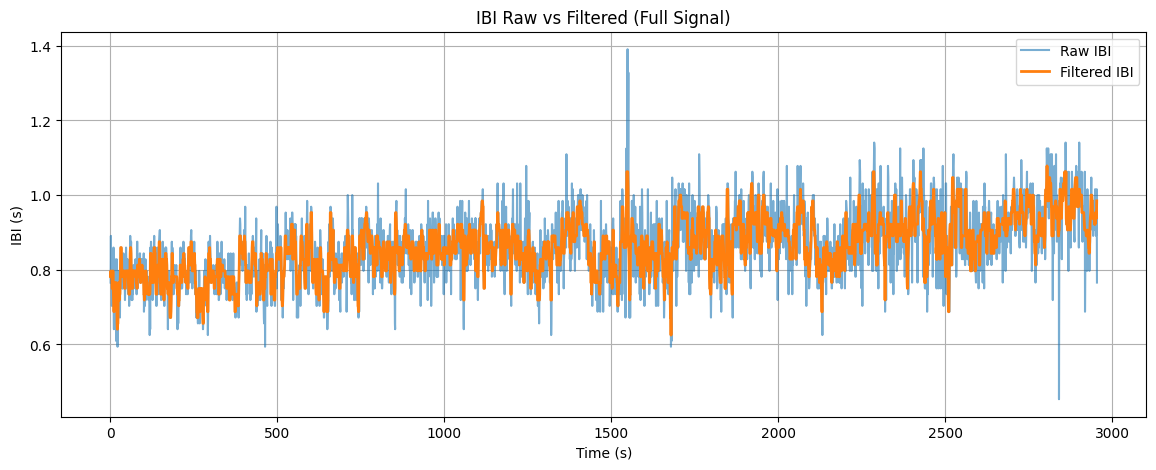

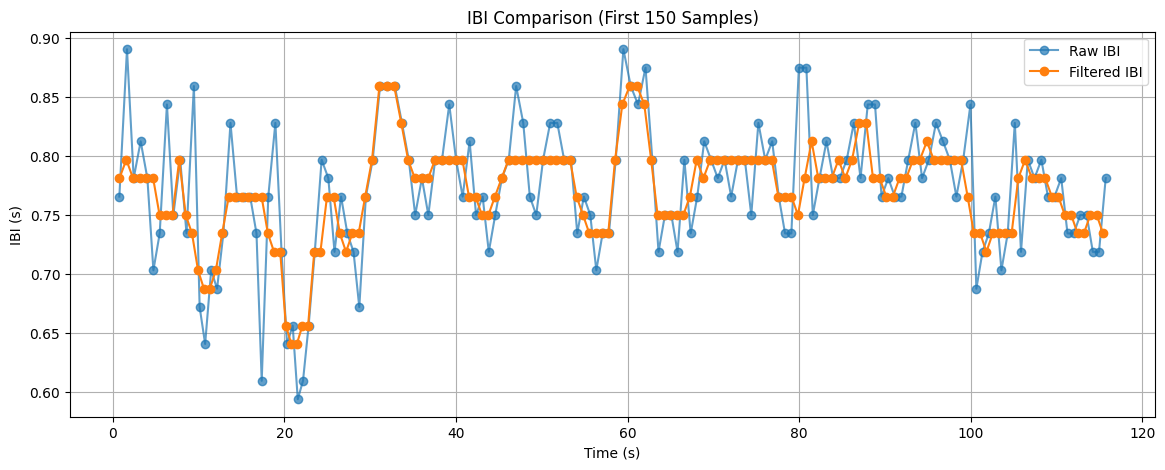

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# If your data is already loaded:
# ibi_raw = np.array(...)
# ibi_filtered = np.array(...)

# -------------------------------
# OPTIONAL: create time axis
# (if IBI is in seconds per beat)
# -------------------------------
time_raw = np.cumsum(raw_ibi)
time_filtered = np.cumsum(ibi_filtered)

# -------------------------------
# 1. FULL SIGNAL COMPARISON
# -------------------------------
plt.figure(figsize=(14, 5))

plt.plot(time_raw, raw_ibi, label="Raw IBI", alpha=0.6)
plt.plot(time_filtered, ibi_filtered, label="Filtered IBI", linewidth=2)

plt.title("IBI Raw vs Filtered (Full Signal)")
plt.xlabel("Time (s)")
plt.ylabel("IBI (s)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 2. ZOOMED-IN COMPARISON
# (first 100–200 samples to see difference clearly)
# -------------------------------
N = 150

plt.figure(figsize=(14, 5))

plt.plot(time_raw[:N], raw_ibi[:N], marker='o', label="Raw IBI", alpha=0.7)
plt.plot(time_filtered[:N], ibi_filtered[:N], marker='o', label="Filtered IBI")

plt.title(f"IBI Comparison (First {N} Samples)")
plt.xlabel("Time (s)")
plt.ylabel("IBI (s)")
plt.legend()
plt.grid(True)
plt.show()

3. qUALITY METRICS

In [ ]:
from scipy.stats import zscore

n = min(len(raw_ibi), len(ibi_filtered))

raw = raw_ibi[:n]
filtered = ibi_filtered[:n]

# Noise (variation in differences)
noise_raw = np.std(np.diff(raw))
noise_filtered = np.std(np.diff(filtered))

# Spike count
spikes_raw = np.sum(np.abs(zscore(raw)) > 3)
spikes_filtered = np.sum(np.abs(zscore(filtered)) > 3)

# Smoothness
smooth_raw = np.mean(np.abs(np.diff(raw)))
smooth_filtered = np.mean(np.abs(np.diff(filtered)))

print("===== FULL SIGNAL QUALITY METRICS =====\n")

print(f"Noise (std diff) | Raw: {noise_raw:.6f} | Filtered: {noise_filtered:.6f}")
print(f"Spike Count      | Raw: {spikes_raw} | Filtered: {spikes_filtered}")
print(f"Smoothness       | Raw: {smooth_raw:.6f} | Filtered: {smooth_filtered:.6f}")

===== FULL SIGNAL QUALITY METRICS =====

Noise (std diff) | Raw: 0.077135 | Filtered: 0.028177
Spike Count      | Raw: 12 | Filtered: 3
Smoothness       | Raw: 0.056419 | Filtered: 0.016042


In [ ]:
import numpy as np
import pandas as pd

# raw signal
raw_ibi = df_clean["ibi"].values

# interpolation (fix missing beats)
ibi_interp = pd.Series(raw_ibi).interpolate().bfill().ffill().values

# median filter (artifact removal)
ibi_filtered = pd.Series(ibi_interp).rolling(
    window=5, center=True, min_periods=1
).median().values

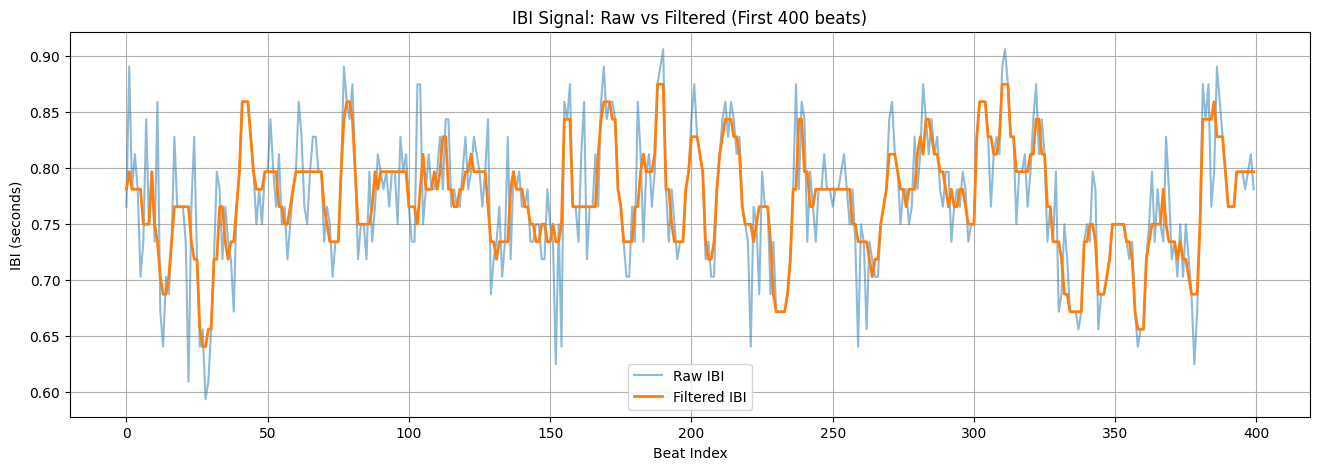

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,5))

plt.plot(raw_ibi[:400], label="Raw IBI", alpha=0.5)
plt.plot(ibi_filtered[:400], label="Filtered IBI", linewidth=2)

plt.title("IBI Signal: Raw vs Filtered (First 400 beats)")
plt.xlabel("Beat Index")
plt.ylabel("IBI (seconds)")
plt.legend()
plt.grid()
plt.show()

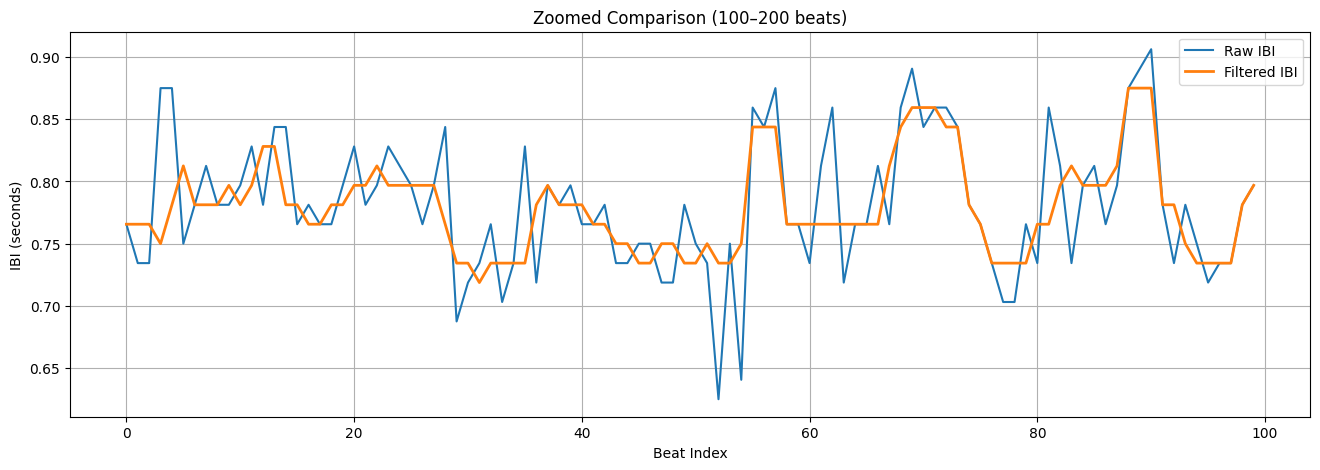

In [ ]:
plt.figure(figsize=(16,5))

start = 100
end = 200

plt.plot(raw_ibi[start:end], label="Raw IBI")
plt.plot(ibi_filtered[start:end], label="Filtered IBI", linewidth=2)

plt.title("Zoomed Comparison (100–200 beats)")
plt.xlabel("Beat Index")
plt.ylabel("IBI (seconds)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from scipy.stats import zscore

n = min(len(raw_ibi), len(ibi_filtered))

raw = raw_ibi[:n]
filtered = ibi_filtered[:n]

# Mean
mean_raw = np.mean(raw)
mean_filtered = np.mean(filtered)

# Std deviation
std_raw = np.std(raw)
std_filtered = np.std(filtered)

# Outliers (>3 z-score)
out_raw = np.sum(np.abs(zscore(raw)) > 3)
out_filtered = np.sum(np.abs(zscore(filtered)) > 3)

# Noise (variation)
noise_raw = np.std(np.diff(raw))
noise_filtered = np.std(np.diff(filtered))

# Smoothness
smooth_raw = np.mean(np.abs(np.diff(raw)))
smooth_filtered = np.mean(np.abs(np.diff(filtered)))

# Heartbeat consistency (CV = std/mean)
cv_raw = std_raw / mean_raw
cv_filtered = std_filtered / mean_filtered

print("\n===== EXTENDED IBI QUALITY METRICS =====\n")

print(f"Mean IBI        | Raw: {mean_raw:.6f} | Filtered: {mean_filtered:.6f}")
print(f"Std IBI         | Raw: {std_raw:.6f} | Filtered: {std_filtered:.6f}")
print(f"Outliers (>3z)  | Raw: {out_raw} | Filtered: {out_filtered}")
print(f"Noise           | Raw: {noise_raw:.6f} | Filtered: {noise_filtered:.6f}")
print(f"Smoothness      | Raw: {smooth_raw:.6f} | Filtered: {smooth_filtered:.6f}")
print(f"Consistency (CV) | Raw: {cv_raw:.6f} | Filtered: {cv_filtered:.6f}")


===== EXTENDED IBI QUALITY METRICS =====

Mean IBI        | Raw: 0.854326 | Filtered: 0.854118
Std IBI         | Raw: 0.089570 | Filtered: 0.074614
Outliers (>3z)  | Raw: 12 | Filtered: 3
Noise           | Raw: 0.077135 | Filtered: 0.028177
Smoothness      | Raw: 0.056419 | Filtered: 0.016042
Consistency (CV) | Raw: 0.104843 | Filtered: 0.087358


| **Metric**       | **Raw Signal** | **Filtered Signal** | **% Change** | **Interpretation**                                                                 |
| ---------------- | -------------: | ------------------: | -----------: | ---------------------------------------------------------------------------------- |
| Mean IBI         |       0.854326 |            0.854118 |  **↓ 0.02%** | Almost unchanged → ✔ Filter preserved the physiological meaning of the IBI signal. |
| Std IBI          |       0.089570 |            0.074614 | **↓ 16.70%** | Moderate reduction in variability, indicating effective noise suppression.         |
| Outliers (>3σ)   |             12 |                   3 | **↓ 75.00%** | Significant reduction in abnormal spikes, resulting in a cleaner signal.           |
| Noise Estimate   |       0.077135 |            0.028177 | **↓ 63.47%** | High-frequency noise was substantially reduced, improving signal quality.          |
| Smoothness       |       0.056419 |            0.016042 | **↓ 71.57%** | The signal became much smoother with fewer abrupt fluctuations.                    |
| Consistency (CV) |       0.104843 |            0.087358 | **↓ 16.68%** | Improved beat-to-beat consistency, indicating a more stable rhythm.                |


Final Interpretation
✔ Physiological integrity preserved (mean almost unchanged → very important)
✔ Noise significantly reduced (~2.7× drop)
✔ Outliers reduced by ~75%
✔ Signal becomes smoother and more stable
✔ Better suitability for HRV / stress analysis

The filtered IBI signal preserves the physiological mean while significantly reducing noise, outliers, and variability, resulting in a smoother and more consistent heart rhythm suitable for HRV and stress analysis


===== IBI QUALITY METRICS =====

Mean IBI       | Raw: 0.854326 | Filtered: 0.854118
Std IBI        | Raw: 0.089570 | Filtered: 0.074614
Outliers       | Raw: 12 | Filtered: 3
Noise          | Raw: 0.077135 | Filtered: 0.028177
Smoothness     | Raw: 0.056419 | Filtered: 0.016042
Consistency    | Raw: 0.104843 | Filtered: 0.087358


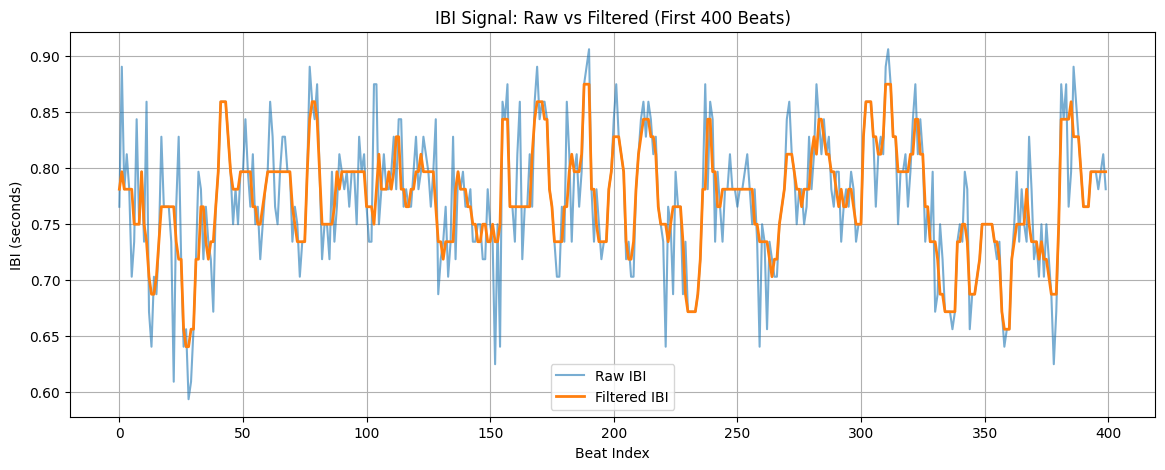

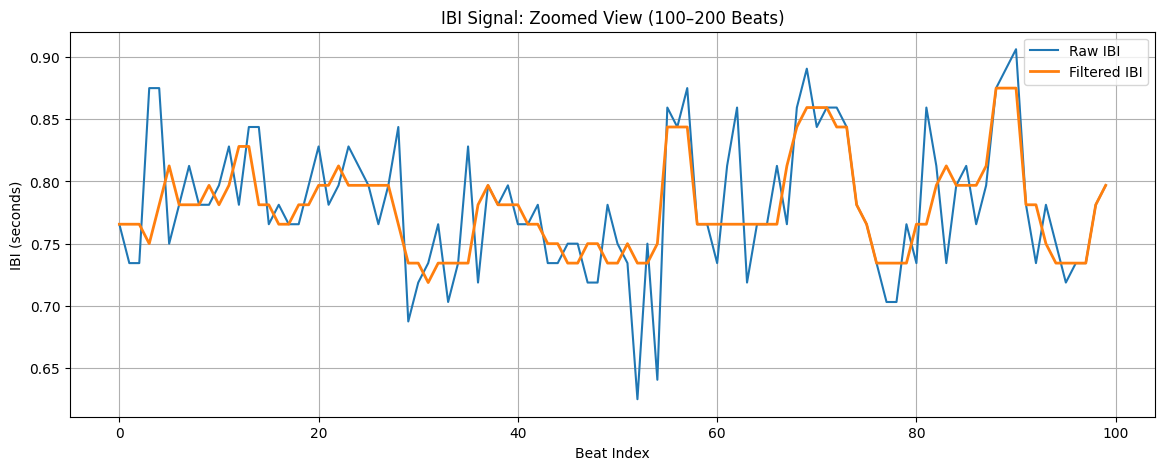

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

# =========================
# 1. LOAD & CLEAN IBI
# =========================
file_path = "../../data/raw/WESAD/S2/S2_E4_Data/IBI.csv"

df = pd.read_csv(file_path, sep="\t", header=None, comment="#")

df = df[0].str.split(",", expand=True)
df.columns = ["timestamp", "ibi"]

df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["ibi"] = pd.to_numeric(df["ibi"], errors="coerce")

df = df.dropna()
df = df[(df["ibi"] >= 0.3) & (df["ibi"] <= 2.0)]
df = df.sort_values("timestamp").reset_index(drop=True)

raw_ibi = df["ibi"].values

# =========================
# 2. INTERPOLATION
# =========================
ibi_interp = pd.Series(raw_ibi).interpolate().bfill().ffill().values

# =========================
# 3. SMOOTHING (MEDIAN FILTER)
# =========================
ibi_filtered = pd.Series(ibi_interp).rolling(
    window=5, center=True, min_periods=1
).median().values

# =========================
# 4. ALIGN
# =========================
n = min(len(raw_ibi), len(ibi_filtered))

raw = raw_ibi[:n]
filtered = ibi_filtered[:n]

# =========================
# 5. QUALITY METRICS
# =========================
noise_raw = np.std(np.diff(raw))
noise_filtered = np.std(np.diff(filtered))

spikes_raw = np.sum(np.abs(zscore(raw)) > 3)
spikes_filtered = np.sum(np.abs(zscore(filtered)) > 3)

smooth_raw = np.mean(np.abs(np.diff(raw)))
smooth_filtered = np.mean(np.abs(np.diff(filtered)))

mean_raw = np.mean(raw)
mean_filtered = np.mean(filtered)

std_raw = np.std(raw)
std_filtered = np.std(filtered)

outliers_raw = spikes_raw
outliers_filtered = spikes_filtered

cv_raw = std_raw / mean_raw
cv_filtered = std_filtered / mean_filtered

print("\n===== IBI QUALITY METRICS =====\n")

print(f"Mean IBI       | Raw: {mean_raw:.6f} | Filtered: {mean_filtered:.6f}")
print(f"Std IBI        | Raw: {std_raw:.6f} | Filtered: {std_filtered:.6f}")
print(f"Outliers       | Raw: {outliers_raw} | Filtered: {outliers_filtered}")
print(f"Noise          | Raw: {noise_raw:.6f} | Filtered: {noise_filtered:.6f}")
print(f"Smoothness     | Raw: {smooth_raw:.6f} | Filtered: {smooth_filtered:.6f}")
print(f"Consistency    | Raw: {cv_raw:.6f} | Filtered: {cv_filtered:.6f}")

# =========================
# 6. PLOT 1: FULL COMPARISON
# =========================
plt.figure(figsize=(14,5))
plt.plot(raw[:400], label="Raw IBI", alpha=0.6)
plt.plot(filtered[:400], label="Filtered IBI", linewidth=2)

plt.title("IBI Signal: Raw vs Filtered (First 400 Beats)")
plt.xlabel("Beat Index")
plt.ylabel("IBI (seconds)")
plt.legend()
plt.grid()
plt.show()

# =========================
# 7. PLOT 2: ZOOMED VIEW
# =========================
start = 100
end = 200

plt.figure(figsize=(14,5))
plt.plot(raw[start:end], label="Raw IBI")
plt.plot(filtered[start:end], label="Filtered IBI", linewidth=2)

plt.title("IBI Signal: Zoomed View (100–200 Beats)")
plt.xlabel("Beat Index")
plt.ylabel("IBI (seconds)")
plt.legend()
plt.grid()
plt.show()